In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [2]:
# width = 1200
# height = 1800
# cutout_left = 900
# cutout_top = 800
width = 1500
height = 1500
cutout_left = 1000
cutout_top = 500

In [3]:
# map x and map y are the map coordinates.
# A map is a view projected over a real world area. 
# The 0, 0 world x, y could be anywhere within the map.
# Remember that the edges are all defined in world coordinates.

margin = 100

wx_range = np.arange(-margin, width + margin)
wy_range = np.arange(-margin, height + margin)
wx_map, wy_map = np.meshgrid(wx_range, wy_range, indexing='ij')
low_probability = 10 ** -10

In [4]:
def plot_map(map_data, axs=None, title=None):
    if axs is None:
        plt.figure(figsize=(8, 8))
        axs = plt.gca()
    if title is not None:
        axs.set_title(title)
    axs.imshow(
        map_data.T,
        cmap='gray',
        origin='lower',
        extent=[wx_range[0], wx_range[-1], wy_range[0], wy_range[-1]]
    )


## Building a distance boundary model

The distance boundary model is similar to the boundary model, instead of modelling if a point is within or outside the boundary, we are modelling if a reading mapping to a point would be on a boundary or not, again this is blurred for a probabilistic reading, given how we know our sensor never gives exact readings.

In [5]:
# We now need to define the edges of our arena and the cutout.
corners = np.array([
    (0, height),
    (width, height),
    (width, cutout_top),
    (cutout_left, cutout_top),
    (cutout_left, 0),
    (0, 0)
])

edges = np.array([
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 0]
])

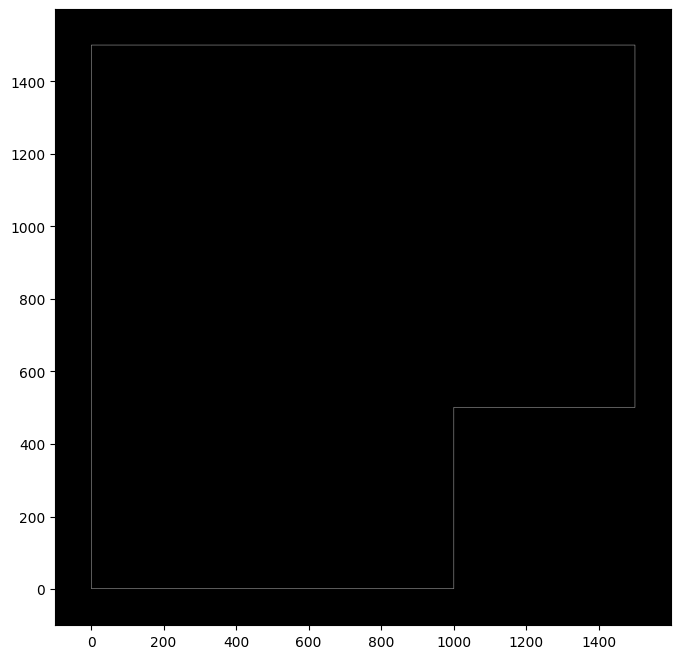

In [31]:
# Intially we draw the boundary with edges that are 1 mm wide
distance_field = np.zeros_like(wx_map, dtype=np.float32)
for edge in edges:
    p1 = corners[edge[0]] + (margin, margin)
    p2 = corners[edge[1]] + (margin, margin)
    cv2.line(distance_field, p1[::-1], p2[::-1], color=1, thickness=1)
# distance_field = distance_field
plot_map(distance_field)

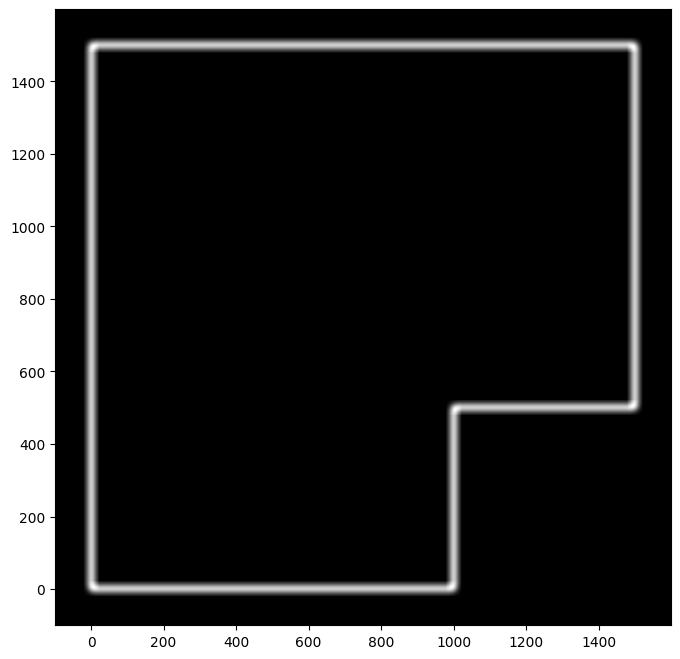

In [32]:
# Since our sensor will not exactly line up, we then blur this boundary into the probabilistic model
distance_span = 41 # This should be set to a value that matches our uncertainty about the sensor reading in mm
blurred_distance = cv2.GaussianBlur(distance_field, (distance_span, distance_span), 10)
plot_map(blurred_distance)

In [33]:
blurred_distance[100, 100]

np.float32(0.04156866)

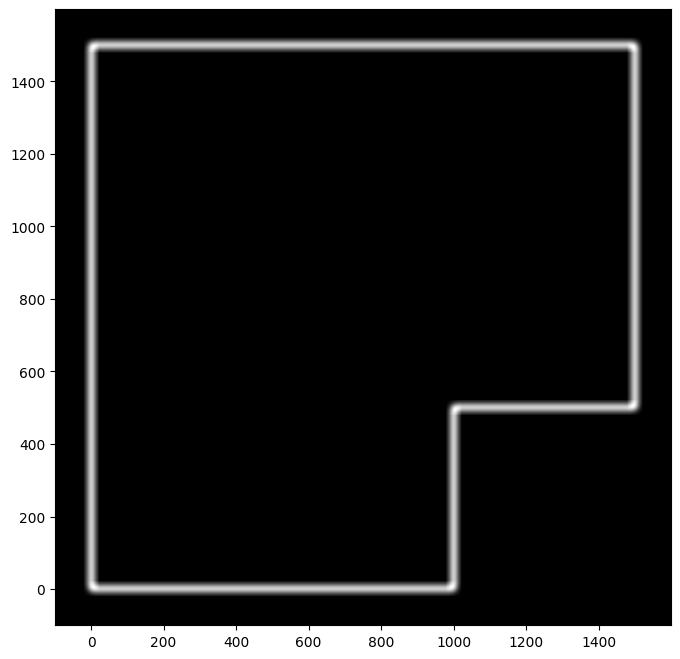

In [34]:
# Scale so every pixel is between 0 and 1
blurred_distance -= blurred_distance.min()
blurred_distance /= blurred_distance.max()
blurred_distance += low_probability
plot_map(blurred_distance)

In [35]:
np.max(blurred_distance)

np.float32(1.0)

In [74]:
blurred_distance[462,1699]

np.float32(1e-10)

## Test data
Let's make some poses to test our model against.

In [19]:
population_size = 20000
rng = np.random.default_rng()
poses = np.column_stack((
            rng.uniform(0, width, population_size),
            rng.uniform(0, height, population_size),
            rng.uniform(0, 2 * np.pi, population_size)
        ))

## Testing sensor obervations against the distance boundary model

We'll start with testing 1 sensor observation. Our sensor makes 64 sensor readings in an 8 by 8 grid, but taking the middle two of a particular row and averaging them gives us a single observation. We can make this work before building more complex models.

In [1]:
sensor_offset = 50,0.0 # mm

The sensor_offset - this is where the sensor surface is located relative to the robot center. In this case, the sensor is 50mm units in front of the robot center.

In [45]:
input_readings = [257.2, 258.1] # mm - these are two middle sensors
# Start by getting the mean (average) of the two readings
distance = np.mean(input_readings)
distance

np.float64(257.65)

In [46]:
# We can now add the middle sensor offset to the reading
reading = distance + robot_middle_to_sensor
reading

np.float64(307.65)

In [50]:
# We now need to use this with each pose to see what the reading would be at that pose
# for each pose
# we project a line the length of the reading in the direction of the pose theta from the pose x, y
# Start by projecting the distance in theta for each pose
projected_readings = np.array([
    reading * np.cos(poses[:,2]), reading * np.sin(poses[:,2])
]).T
print(np.shape(projected_readings), # should be a poses times (x, y)
poses[0], projected_readings[0])

(20000, 2) [147.38625088 929.87920567   5.99779774] [295.20636181 -86.61250744]


In [51]:
# Now we add pose x, y to projected reading
reading_coordinates = poses[:,:2] + projected_readings
print(np.shape(reading_coordinates),# should be nposes, 2
reading_coordinates[0])

(20000, 2) [442.5926127  843.26669823]


In [52]:
# make these integers for indexing
reading_coordinates = reading_coordinates.astype(int)
print(np.shape(reading_coordinates),# should be nposes, 2
reading_coordinates[0])

(20000, 2) [442 843]


In [53]:
# Shift this by adding the margin
reading_coordinates += margin
print(np.shape(reading_coordinates),# should be nposes, 2
reading_coordinates[0])

(20000, 2) [542 943]


In [54]:
# Now we need to looking up the probability of each reading in the blurred distance field
pose_weights = blurred_distance[reading_coordinates]
print(np.shape(pose_weights), # should be nposes
pose_weights[0:10])

IndexError: index 1894 is out of bounds for axis 0 with size 1700

Hmm - problem, projecting the readings will result in coordinates far past the boundary. We can clip them to a boundary, since being at the margine on a boundary will result in the low weight setting

In [55]:
print(np.max(reading_coordinates, axis=0), np.min(reading_coordinates, axis=0))

[1904 1902] [-205 -205]


In [76]:
# Restrict reading_coordinates to be within the valid range of grid coordinates, 0 to width + margin * 2 - 1, 
# #0 to height + margin * 2 - 1
clipped_coordinates = np.copy(reading_coordinates)
clipped_coordinates[:, 0] = np.clip(reading_coordinates[:, 0], 0, np.shape(blurred_distance)[0] - 1)
clipped_coordinates[:, 1] = np.clip(reading_coordinates[:, 1], 0, np.shape(blurred_distance)[1] - 1)
print(np.max(clipped_coordinates, axis=0), np.min(clipped_coordinates, axis=0))

[1699 1699] [0 0]


In [77]:
# Try the looking again
pose_weights = blurred_distance[clipped_coordinates[:, 0], clipped_coordinates[:, 1]]
print(np.shape(pose_weights), # should be nposes by 1
pose_weights[15:20], clipped_coordinates[15:20, 0], clipped_coordinates[15:20, 1])

(20000,) [1.0000000e-10 1.0000000e-10 1.0000000e-10 1.9098945e-01 6.3410735e-01] [   0  462 1133 1129   93] [ 601 1699  683  617 1139]


Let's turn this result into a map, so we can see what is going on.
Start with the blurred distance field as a background.
We'll plot the original (unclipped coordinates) as a line from a dot for each pose. We'll paint the pose on this as a dot in a heat colourmap according to the weight.

/tmp/ipykernel_83633/1860900497.py:15: UserWarning: Adding colorbar to a different Figure <Figure size 800x800 with 3 Axes> than <Figure size 800x800 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(sc, label='Pose Weight')


<Figure size 800x800 with 0 Axes>

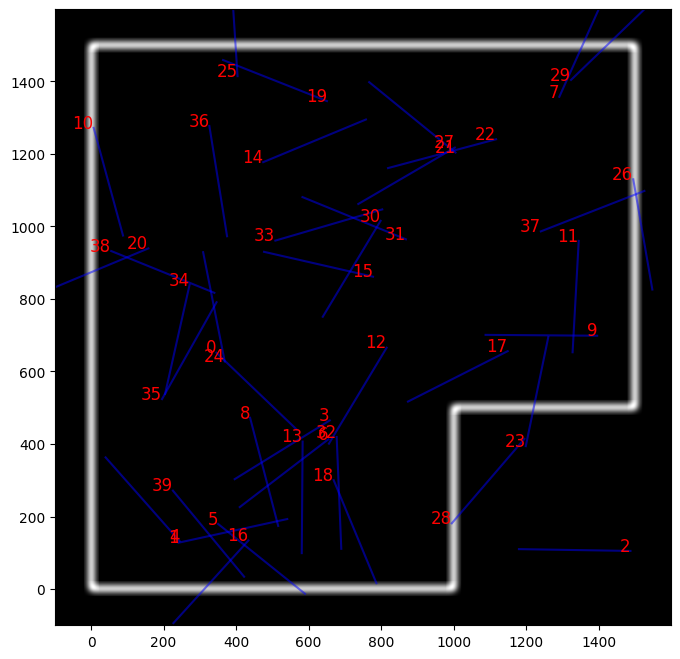

In [96]:
plt.figure(figsize=(8, 8))
plot_map(blurred_distance)
sample_set = slice(80, 120)
restored_coordinates = clipped_coordinates - margin 
# # plt.plot(poses_translated[sample_set,0], poses_translated[sample_set,1], 'ro')  # Pose position
# # Draw a line from each pose to its reading coordinate - stack into start/end arrays, then plot as lines
cmap = plt.get_cmap('hot')
norm = plt.Normalize(vmin=np.min(pose_weights), vmax=np.max(pose_weights))
for n, (start, end) in enumerate(zip(poses[sample_set], restored_coordinates[sample_set])):
    plt.plot([start[0], end[0]], [start[1], end[1]], '-', c='blue', alpha=0.5)
    plt.text(start[0], start[1], str(n), fontsize=12, ha='right', c='red')

# sc= plt.scatter(poses[sample_set,0], poses[sample_set,1], c=pose_weights[sample_set], cmap='hot')
# # Color scale
plt.colorbar(sc, label='Pose Weight')
# list(enumerate(zip(pose_weights[sample_set], clipped_coordinates[sample_set])))